In [56]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

np.random.seed(42)
sns.set_style("whitegrid")

In [57]:
N_stocks = 10
N_days = 500
P0 = 100.0

mu = np.random.uniform(0.0001, 0.0005, N_stocks)
beta = np.random.uniform(0.5, 1.5, N_stocks)
sigma = np.random.uniform(0.005, 0.02, N_stocks)

def generate_prices(mu, beta, sigma, n_days=N_days, p0=P0, seed=None):
    """Simulate price paths under the factor-model DGP."""
    rng = np.random.default_rng(seed)
    f = rng.normal(0.0, np.sqrt(0.01), n_days)
    eps = rng.normal(0.0, 1.0, (n_days, len(mu))) * sigma
    prices = np.zeros((n_days + 1, len(mu)))
    prices[0] = p0
    for t in range(1, n_days + 1):
        prices[t] = prices[t - 1] * np.exp(mu + beta * f[t - 1] + eps[t - 1])
    return prices, f

prices, f_common = generate_prices(mu, beta, sigma, seed=123)

def compute_log_returns(prices):
    return np.log(prices[1:] / prices[:-1])

returns = compute_log_returns(prices)
scaler_full = StandardScaler()
standardized_returns = scaler_full.fit_transform(returns)

stock_names = [f"Stock {i+1}" for i in range(N_stocks)]
print("returns shape:", returns.shape)

returns shape: (500, 10)


In [72]:
def cosine_similarity(v1, v2):
    """Cosine similarity between two vectors (used throughout Part 6)."""
    return np.dot(v1, v2) / (np.linalg.norm(v1) * np.linalg.norm(v2))

In [59]:
def fit_pca_on_window(data_window, n_components=3):
    """Standardize a window of raw returns and fit PCA on it."""
    std_data = StandardScaler().fit_transform(data_window)
    pca = PCA(n_components=n_components)
    pca.fit(std_data)
    return pca

half = N_days // 2
returns_first_half  = returns[:half]
returns_second_half = returns[half:]

pca_first  = fit_pca_on_window(returns_first_half)
pca_second = fit_pca_on_window(returns_second_half)

cos_sims_raw, cos_sims_abs = [], []
for i in range(3):
    sim = cosine_similarity(pca_first.components_[i], pca_second.components_[i])
    cos_sims_raw.append(sim)
    cos_sims_abs.append(abs(sim))
    print(f"PC{i+1}: cosine similarity (first half vs second half) = {sim:+.4f}  "
          f"(|.| = {abs(sim):.4f})")

PC1: cosine similarity (first half vs second half) = +1.0000  (|.| = 1.0000)
PC2: cosine similarity (first half vs second half) = -0.8820  (|.| = 0.8820)
PC3: cosine similarity (first half vs second half) = +0.8803  (|.| = 0.8803)


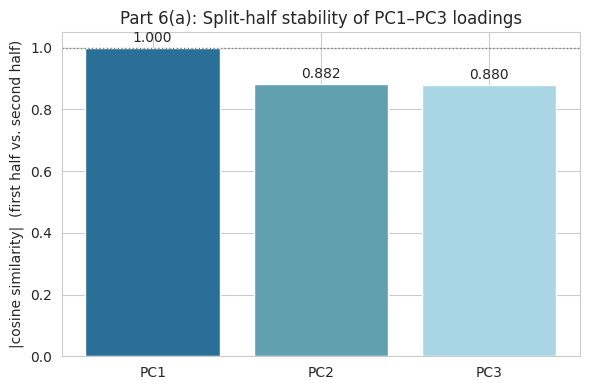

In [60]:
fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar([f"PC{i+1}" for i in range(3)], cos_sims_abs,
              color=["#2a6f97", "#61a0af", "#a9d6e5"])
ax.axhline(1.0, color="gray", linestyle=":", linewidth=1)
ax.set_ylim(0, 1.05)
ax.set_ylabel("|cosine similarity|  (first half vs. second half)")
ax.set_title("Part 6(a): Split-half stability of PC1–PC3 loadings")
for b, v in zip(bars, cos_sims_abs):
    ax.text(b.get_x() + b.get_width()/2, v + 0.02, f"{v:.3f}", ha="center")
plt.tight_layout()
plt.show()

In [61]:
def rolling_pca(returns_arr, window=100, step=20, n_components=3):
    """Fit PCA on each rolling window of raw returns.
    Returns a list of dicts: start index, end index, eigenvalues, loadings (n_components x n_stocks).
    """
    results = []
    for start in range(0, len(returns_arr) - window + 1, step):
        window_data = returns_arr[start:start + window]
        std_data = StandardScaler().fit_transform(window_data)
        pca = PCA(n_components=n_components)
        pca.fit(std_data)
        results.append({
            "start": start,
            "end": start + window,
            "eigenvalues": pca.explained_variance_,
            "loadings": pca.components_.copy(),
        })
    return results

rolling_results = rolling_pca(returns, window=100, step=20, n_components=3)
print(f"Number of rolling windows: {len(rolling_results)}")

pc1_loadings_over_time = np.array([r["loadings"][0] for r in rolling_results])
window_starts = [r["start"] for r in rolling_results]

Number of rolling windows: 21


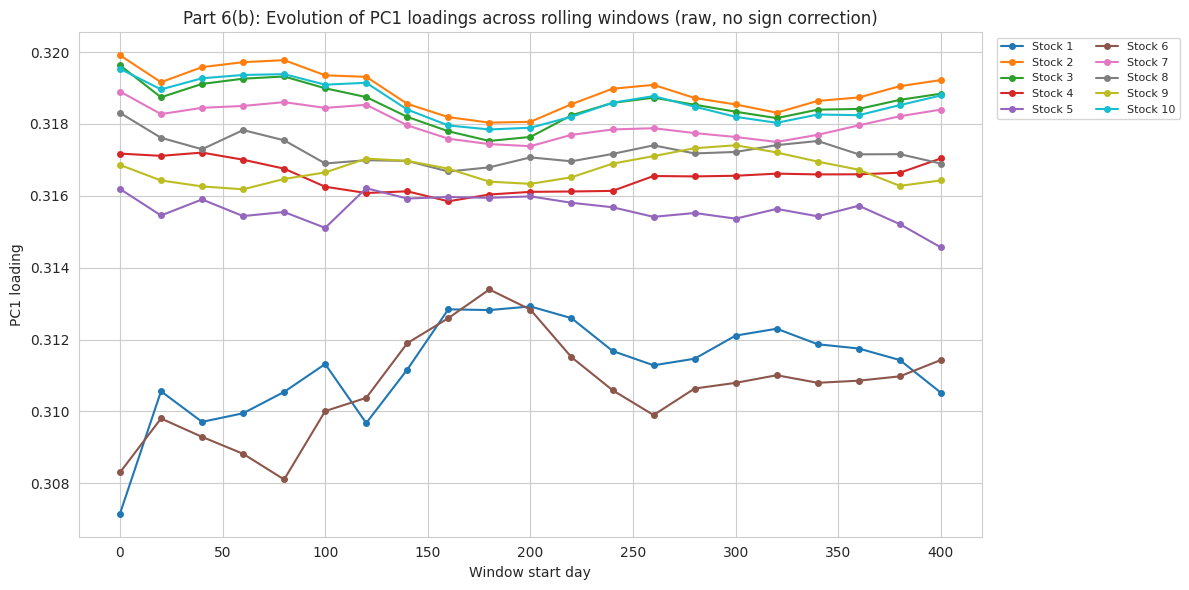

In [62]:
fig, ax = plt.subplots(figsize=(12, 6))
for s in range(N_stocks):
    ax.plot(window_starts, pc1_loadings_over_time[:, s], marker="o", markersize=4, label=stock_names[s])
ax.set_xlabel("Window start day")
ax.set_ylabel("PC1 loading")
ax.set_title("Part 6(b): Evolution of PC1 loadings across rolling windows (raw, no sign correction)")
ax.legend(ncol=2, fontsize=8, loc="upper left", bbox_to_anchor=(1.01, 1.0))
plt.tight_layout()
plt.show()

In [63]:
def correct_sign_flips(loadings_over_time):
    """
    For each time step t > 0: if cosine_similarity(loadings[t], corrected[t-1]) < 0,
    flip loadings[t] *= -1.
    """
    corrected = [loadings_over_time[0].copy()]
    for t in range(1, len(loadings_over_time)):
        sim = cosine_similarity(loadings_over_time[t], corrected[-1])
        if sim < 0:
            corrected.append(-loadings_over_time[t])
        else:
            corrected.append(loadings_over_time[t].copy())
    return np.array(corrected)

pc1_corrected = correct_sign_flips(pc1_loadings_over_time)

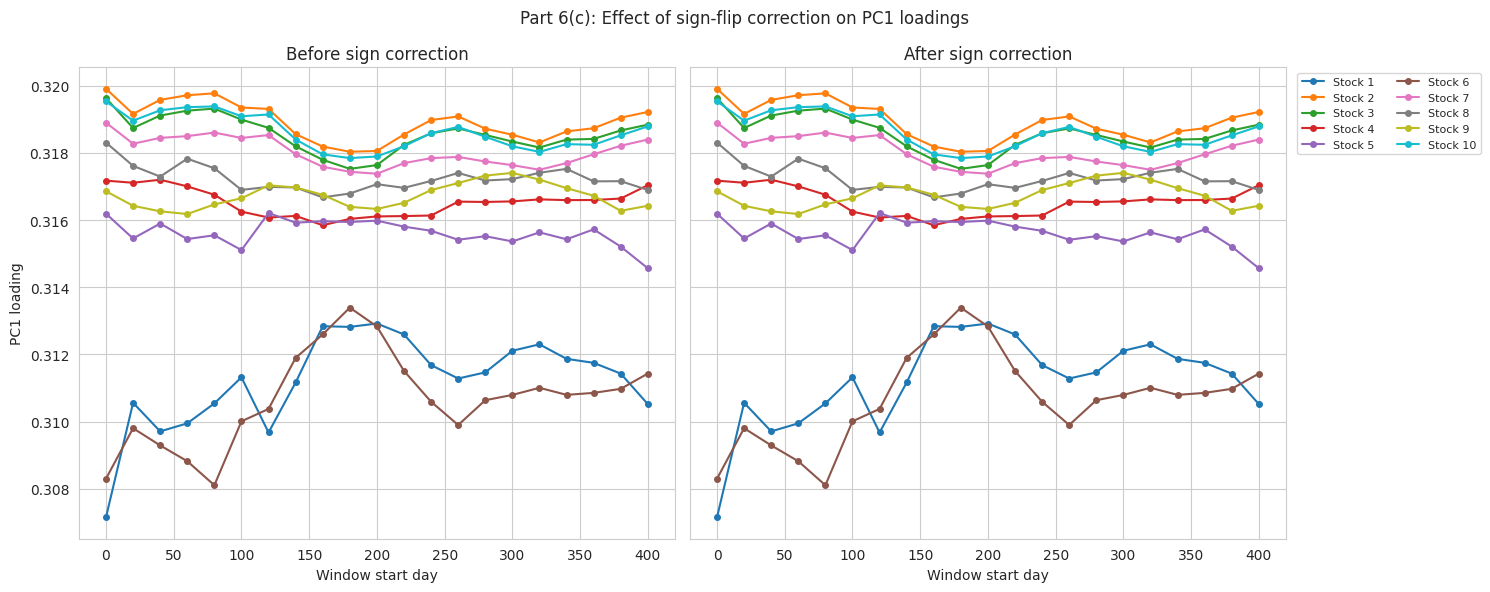

In [64]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6), sharey=True)
for s in range(N_stocks):
    axes[0].plot(window_starts, pc1_loadings_over_time[:, s], marker="o", markersize=4)
    axes[1].plot(window_starts, pc1_corrected[:, s], marker="o", markersize=4, label=stock_names[s])
axes[0].set_title("Before sign correction")
axes[1].set_title("After sign correction")
for ax in axes:
    ax.set_xlabel("Window start day")
axes[0].set_ylabel("PC1 loading")
axes[1].legend(ncol=2, fontsize=8, loc="upper left", bbox_to_anchor=(1.01, 1.0))
fig.suptitle("Part 6(c): Effect of sign-flip correction on PC1 loadings")
plt.tight_layout()
plt.show()

In [65]:
beta_swapped = beta.copy()
beta_swapped[:5] = beta[5:10]
beta_swapped[5:10] = beta[:5]

def generate_prices_regime_change(mu, beta_first, beta_second, sigma, switch_day=250,
                                    n_days=N_days, p0=P0, seed=None):
    """Same DGP as generate_prices, but beta switches from beta_first to beta_second
    after `switch_day`."""
    rng = np.random.default_rng(seed)
    f = rng.normal(0.0, np.sqrt(0.01), n_days)
    eps = rng.normal(0.0, 1.0, (n_days, len(mu))) * sigma
    prices = np.zeros((n_days + 1, len(mu)))
    prices[0] = p0
    for t in range(1, n_days + 1):
        b = beta_first if t <= switch_day else beta_second
        prices[t] = prices[t - 1] * np.exp(mu + b * f[t - 1] + eps[t - 1])
    return prices, f

prices_regime, f_regime = generate_prices_regime_change(
    mu, beta, beta_swapped, sigma, switch_day=250, seed=456
)
returns_regime = compute_log_returns(prices_regime)
print("returns_regime shape:", returns_regime.shape)

returns_regime shape: (500, 10)


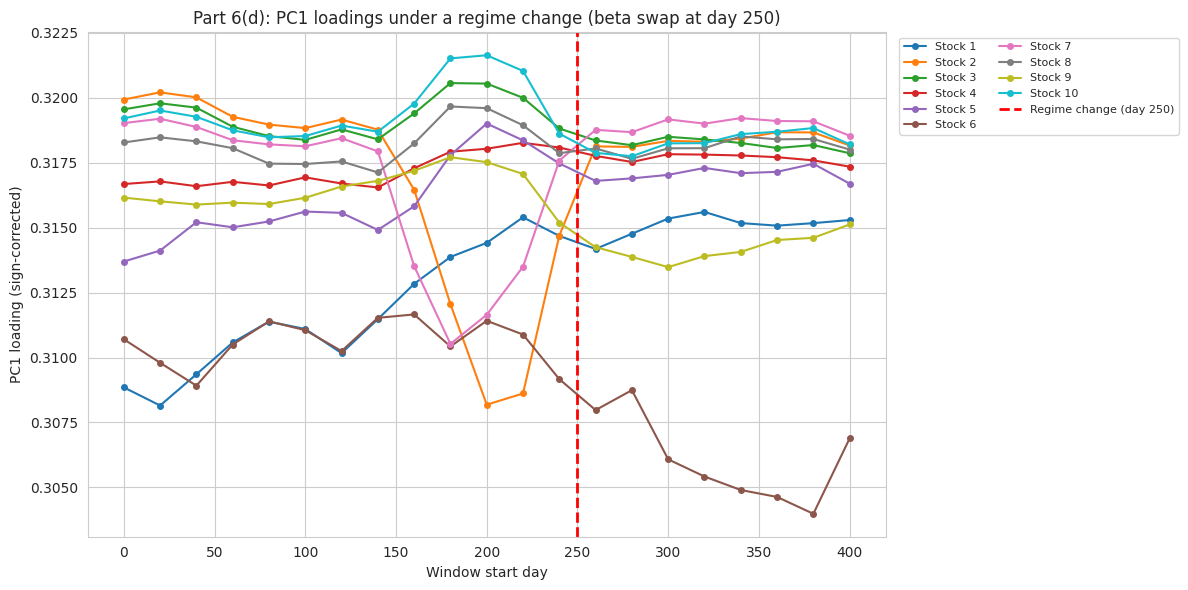

In [66]:
rolling_results_regime = rolling_pca(returns_regime, window=100, step=20, n_components=3)
pc1_regime = np.array([r["loadings"][0] for r in rolling_results_regime])
window_starts_regime = [r["start"] for r in rolling_results_regime]
pc1_regime_corrected = correct_sign_flips(pc1_regime)

fig, ax = plt.subplots(figsize=(12, 6))
for s in range(N_stocks):
    ax.plot(window_starts_regime, pc1_regime_corrected[:, s], marker="o", markersize=4, label=stock_names[s])
ax.axvline(250, color="red", linestyle="--", linewidth=2, label="Regime change (day 250)")
ax.set_xlabel("Window start day")
ax.set_ylabel("PC1 loading (sign-corrected)")
ax.set_title("Part 6(d): PC1 loadings under a regime change (beta swap at day 250)")
ax.legend(ncol=2, fontsize=8, loc="upper left", bbox_to_anchor=(1.01, 1.0))
plt.tight_layout()
plt.show()

In [67]:
def construct_neutral_portfolio(target_weights, loadings, neutral_pcs=(0,)):
    """
    Find weights w closest to target_weights (in squared-error sense) such that:
      1. w @ loadings[pc] = 0 for each pc in neutral_pcs   (factor neutral)
      2. sum(w) = 0                                         (dollar neutral)
    Solved via the Lagrangian / constrained least-squares projection onto the constraint
    set: w = target - A.T @ (A A.T)^-1 @ (A @ target - b), with A stacking the constraint
    rows and b = 0.
    """
    n = len(target_weights)
    A_rows = [loadings[pc] for pc in neutral_pcs]
    A_rows.append(np.ones(n))
    A = np.array(A_rows)
    b = np.zeros(len(A_rows))
    AAt = A @ A.T
    lam = np.linalg.solve(AAt, A @ target_weights - b)
    w = target_weights - A.T @ lam
    return w

def backtest_metrics(daily_returns):
    """Cumulative return, annualized vol, Sharpe ratio, max drawdown for a return series."""
    daily_returns = np.asarray(daily_returns)
    if len(daily_returns) == 0:
        return dict(cumulative_return=np.nan, annualized_vol=np.nan,
                    sharpe_ratio=np.nan, max_drawdown=np.nan)
    cum_curve = np.cumprod(1 + daily_returns)
    cumulative_return = cum_curve[-1] - 1
    ann_vol = np.std(daily_returns) * np.sqrt(252)
    ann_return = np.mean(daily_returns) * 252
    sharpe = ann_return / ann_vol if ann_vol > 0 else np.nan
    running_max = np.maximum.accumulate(cum_curve)
    drawdown = (cum_curve - running_max) / running_max
    max_dd = drawdown.min()
    return dict(cumulative_return=cumulative_return, annualized_vol=ann_vol,
                sharpe_ratio=sharpe, max_drawdown=max_dd)

In [68]:
def walk_forward_vs_oracle(returns_arr, window=100, step=20, target_weights=None, neutral_pcs=(0,)):
    """
    Compare a walk-forward factor-neutral strategy (hedge built from PAST data only) to an
    oracle strategy (hedge built from the FUTURE realized data of the holding period).
    Returns daily return series for both, plus the day index of each return.
    """
    n_days, n_stocks = returns_arr.shape
    if target_weights is None:
        target_weights = np.array([0.2, 0.2, 0.2, 0.2, 0.2, 0, 0, 0, 0, 0])
    n_pc_needed = max(neutral_pcs) + 1

    wf_returns, oracle_returns, day_idx = [], [], []
    for start in range(window, n_days - 1, step):
        # Walk-forward: PCA fit on the PAST window only
        past_data = returns_arr[start - window:start]
        std_past = StandardScaler().fit_transform(past_data)
        pca_wf = PCA(n_components=n_pc_needed).fit(std_past)
        w_wf = construct_neutral_portfolio(target_weights, pca_wf.components_, neutral_pcs)

        # Oracle: PCA fit on the FUTURE window being hedged (look-ahead, by construction)
        future_end = min(start + window, n_days)
        future_data = returns_arr[start:future_end]
        if len(future_data) < 10:
            continue
        std_future = StandardScaler().fit_transform(future_data)
        pca_or = PCA(n_components=n_pc_needed).fit(std_future)
        w_or = construct_neutral_portfolio(target_weights, pca_or.components_, neutral_pcs)

        # Hold both portfolios over the next `step` days
        period_end = min(start + step, n_days)
        period_returns = returns_arr[start:period_end]

        wf_returns.extend((period_returns @ w_wf).tolist())
        oracle_returns.extend((period_returns @ w_or).tolist())
        day_idx.extend(range(start, period_end))

    return np.array(wf_returns), np.array(oracle_returns), np.array(day_idx)

wf_ret, oracle_ret, day_idx = walk_forward_vs_oracle(returns, window=100, step=20)
wf_metrics = backtest_metrics(wf_ret)
oracle_metrics = backtest_metrics(oracle_ret)

print("Walk-forward metrics:", {k: round(v, 4) for k, v in wf_metrics.items()})
print("Oracle metrics      :", {k: round(v, 4) for k, v in oracle_metrics.items()})
print(f"Performance gap (Sharpe, oracle - walk-forward): "
      f"{oracle_metrics['sharpe_ratio'] - wf_metrics['sharpe_ratio']:.4f}")
print(f"Performance gap (cumulative return, oracle - walk-forward): "
      f"{oracle_metrics['cumulative_return'] - wf_metrics['cumulative_return']:.4f}")

Walk-forward metrics: {'cumulative_return': np.float64(0.1457), 'annualized_vol': np.float64(0.1005), 'sharpe_ratio': np.float64(0.903), 'max_drawdown': np.float64(-0.057)}
Oracle metrics      : {'cumulative_return': np.float64(0.1486), 'annualized_vol': np.float64(0.1077), 'sharpe_ratio': np.float64(0.8642), 'max_drawdown': np.float64(-0.0757)}
Performance gap (Sharpe, oracle - walk-forward): -0.0388
Performance gap (cumulative return, oracle - walk-forward): 0.0028


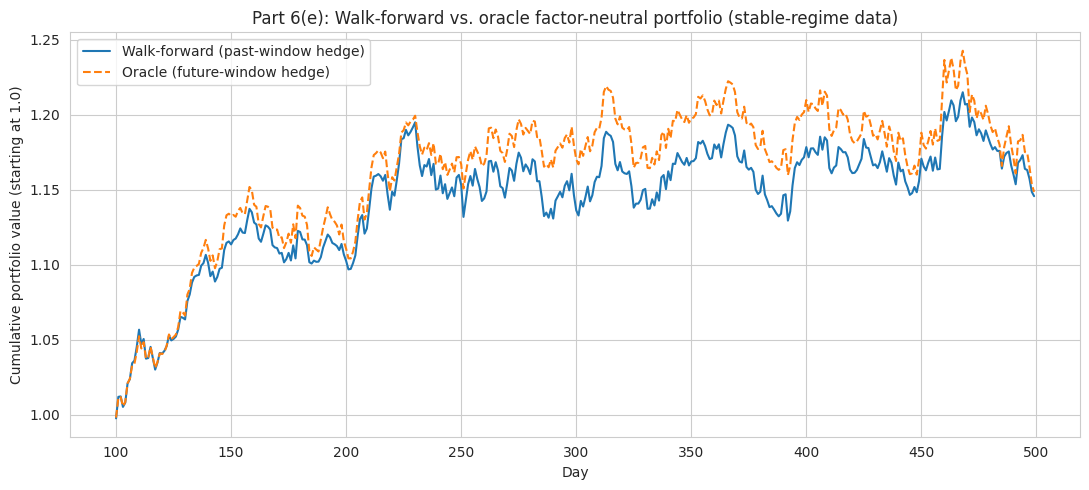

In [69]:
fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(day_idx, np.cumprod(1 + wf_ret), label="Walk-forward (past-window hedge)")
ax.plot(day_idx, np.cumprod(1 + oracle_ret), label="Oracle (future-window hedge)", linestyle="--")
ax.set_xlabel("Day")
ax.set_ylabel("Cumulative portfolio value (starting at 1.0)")
ax.set_title("Part 6(e): Walk-forward vs. oracle factor-neutral portfolio (stable-regime data)")
ax.legend()
plt.tight_layout()
plt.show()

In [70]:
wf_ret_regime, oracle_ret_regime, day_idx_regime = walk_forward_vs_oracle(
    returns_regime, window=100, step=20
)
wf_metrics_regime = backtest_metrics(wf_ret_regime)
oracle_metrics_regime = backtest_metrics(oracle_ret_regime)

print("Walk-forward metrics (regime-change data):",
      {k: round(v, 4) for k, v in wf_metrics_regime.items()})
print("Oracle metrics       (regime-change data):",
      {k: round(v, 4) for k, v in oracle_metrics_regime.items()})


gap_regime = np.abs(oracle_ret_regime - wf_ret_regime)
near_boundary = (day_idx_regime >= 230) & (day_idx_regime <= 270)
print(f"\nMean |oracle - walk-forward| daily return, near boundary (days 230-270): "
      f"{gap_regime[near_boundary].mean():.5f}")
print(f"Mean |oracle - walk-forward| daily return, elsewhere               : "
      f"{gap_regime[~near_boundary].mean():.5f}")

Walk-forward metrics (regime-change data): {'cumulative_return': np.float64(-0.2277), 'annualized_vol': np.float64(0.135), 'sharpe_ratio': np.float64(-1.1376), 'max_drawdown': np.float64(-0.3074)}
Oracle metrics       (regime-change data): {'cumulative_return': np.float64(-0.2723), 'annualized_vol': np.float64(0.147), 'sharpe_ratio': np.float64(-1.288), 'max_drawdown': np.float64(-0.3253)}

Mean |oracle - walk-forward| daily return, near boundary (days 230-270): 0.00287
Mean |oracle - walk-forward| daily return, elsewhere               : 0.00182


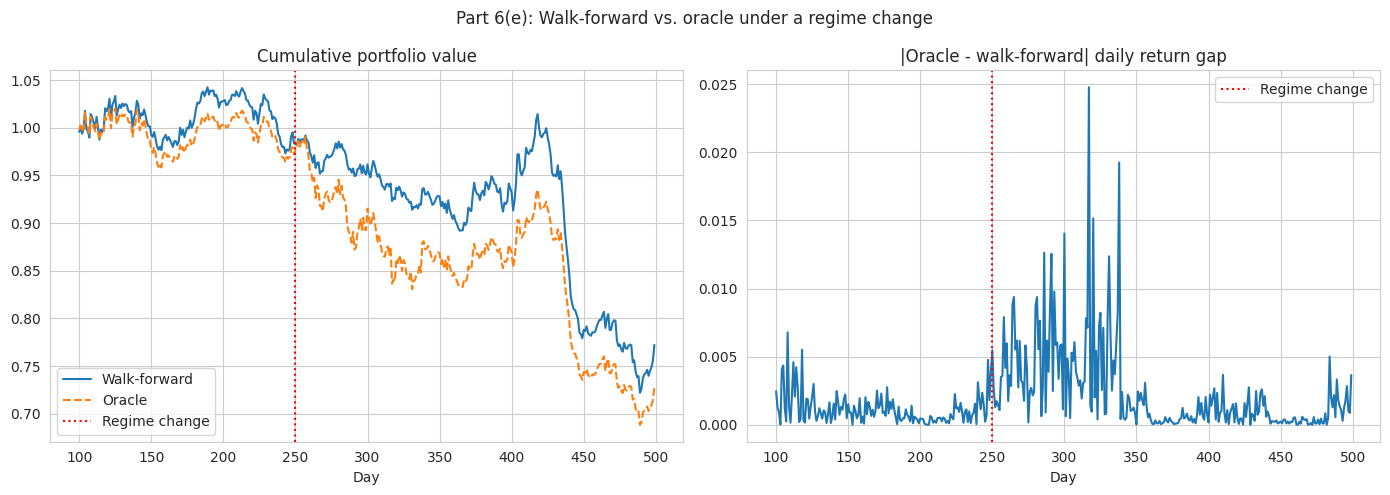

In [71]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(day_idx_regime, np.cumprod(1 + wf_ret_regime), label="Walk-forward")
axes[0].plot(day_idx_regime, np.cumprod(1 + oracle_ret_regime), label="Oracle", linestyle="--")
axes[0].axvline(250, color="red", linestyle=":", label="Regime change")
axes[0].set_title("Cumulative portfolio value")
axes[0].set_xlabel("Day")
axes[0].legend()

axes[1].plot(day_idx_regime, gap_regime)
axes[1].axvline(250, color="red", linestyle=":", label="Regime change")
axes[1].set_title("|Oracle - walk-forward| daily return gap")
axes[1].set_xlabel("Day")
axes[1].legend()

fig.suptitle("Part 6(e): Walk-forward vs. oracle under a regime change")
plt.tight_layout()
plt.show()

### **Part 6(f): When PCA Works vs. When It Breaks**

#### **When PCA is Reliable**

*
**Stable Market:** Asset behaviors, sensitivities ($\beta$), and volatilities ($\sigma$) do not change over time.


*
**Dominant Market Trend:** One clear factor (like a market-wide trend in PC1) explains most of the variance.


*
**Linear Movements:** Stocks move in straight, synchronized linear patterns.


*
**Enough Historical Data:** The data tracking window is long enough to smooth out temporary noise.



#### **When PCA Breaks Down**

*
**Regime Shifts:** Sudden market structural changes (like a sector rotation) make older models obsolete and destroy your portfolio hedges.


*
**Sign Flipping:** Eigenvectors can randomly flip directions ($180^\circ$) between tracking windows, creating fake data spikes if left uncorrected.


*
**Information Leakage:** Mixing future data with past data incorrectly hides real tracking errors and understates out-of-sample risk.


*
**Too Much Noise:** When asset movements are random and flat, PCA captures pure noise instead of a clean, stable signal.